In [1]:
#first we need to import the basic libs :
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
df = pd.read_csv('student_habits_performance.csv')
# we want to show first few rows
df.head()

,age,study_hours_per_day,social_media_hours,attendance_percentage,sleep_hours,mental_health_rating,exam_score
0,23,0.0,1.2,85.0,8.0,8,56.2
1,20,6.9,2.8,97.3,4.6,8,100.0
2,21,1.4,3.1,94.8,8.0,1,34.3
3,23,1.0,3.9,71.0,9.2,1,26.8
4,19,5.0,4.4,90.9,4.9,1,66.4


In [3]:
#now we want to get a quick summary of what we have
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1000 non-null   int64  
 1   study_hours_per_day    1000 non-null   float64
 2   social_media_hours     1000 non-null   float64
 3   attendance_percentage  1000 non-null   float64
 4   sleep_hours            1000 non-null   float64
 5   mental_health_rating   1000 non-null   int64  
 6   exam_score             1000 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 54.8 KB


,age,study_hours_per_day,social_media_hours,attendance_percentage,sleep_hours,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,84.131700,6.470100,5.438000,69.601500
std,2.3081,1.46889,1.172422,9.399246,1.226377,2.847501,16.888564
min,17.0000,0.00000,0.000000,56.000000,3.200000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,78.000000,5.600000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,84.400000,6.500000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,91.025000,7.300000,8.000000,81.325000
max,24.0000,8.30000,7.200000,100.000000,10.000000,10.000000,100.000000


In [4]:
#now we need to find missing values
#from pandas ducm we can find that : "isna() or notna() will also consider None a missing value."
df.isna().sum

<bound method DataFrame.sum of        age  study_hours_per_day  social_media_hours  attendance_percentage  \
0    False                False               False                  False   
1    False                False               False                  False   
2    False                False               False                  False   
3    False                False               False                  False   
4    False                False               False                  False   
..     ...                  ...                 ...                    ...   
995  False                False               False                  False   
996  False                False               False                  False   
997  False                False               False                  False   
998  False                False               False                  False   
999  False                False               False                  False   

     sleep_hours  mental_health_

In [5]:
df.columns
#these are the columns of our data that later on will be the parameters for us.

Index(['age', 'study_hours_per_day', 'social_media_hours',
       'attendance_percentage', 'sleep_hours', 'mental_health_rating',
       'exam_score'],
      dtype='object')

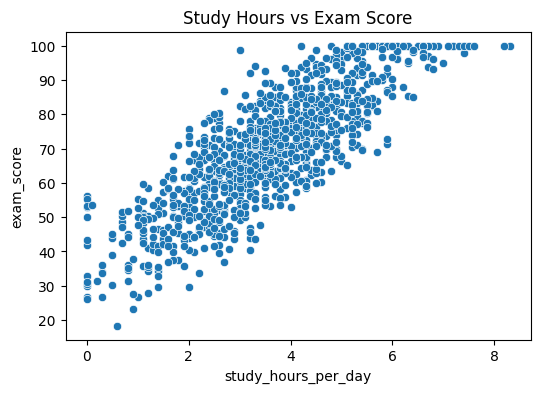

In [6]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="study_hours_per_day", y="exam_score", data=df)
plt.title("Study Hours vs Exam Score")
plt.show()


In [7]:
#as we can see the data is a good for a regression model ! :)

In [8]:
#now we can brin sk learning into play and start the scaling and spliting prossess :
#for test /train split :
from sklearn.model_selection import train_test_split
#for scalling prossess:
from sklearn.preprocessing import StandardScaler
#now we need to point what is X and what is y
#the results whould be y and the parameters are the culumns:
x= df.drop(columns=(['exam_score']) )
#drop will return values without the labes
y = df['exam_score']
# Split: 70% train, 15% validation, 15% test #these are the standard ML split :
X_train, X_temp, y_train, y_temp = train_test_split(x,y,test_size=0.3,random_state=42)
#now we want to say the 30 perc that we used for testing should be half test half validate:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
#now we chceck print :
print('Train size:', len(X_train) )
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 700
Validation size: 150
Test size: 150


In [9]:
# now for scaling prosses :
scaler = StandardScaler()
X_train_scaled =scaler.fit_transform(X_train) #We fit the scaler only on the training data to avoid leaking information about the validation/test data.
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [10]:
#we are finally ready to use tensorflow and start the layers and training pross
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
n_features = X_train_scaled.shape[1] # .shape will find dim of arrays 
model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(16, activation = 'relu' ),
    layers.Dense(1) # = this line is output so no activation 
])
# Python compile() function takes source code as input and returns a code object that is ready to be executed and which can later be executed by the exec() function.
#now we need to compile :
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss= 'mse', #mse is mean square error
    metrics=[keras.metrics.MeanAbsoluteError(name='mae')]
)
#now lets check summary
model.summary()

2025-10-20 15:46:30.832221: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-20 15:46:30.832683: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-20 15:46:30.898849: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-20 15:46:32.943498: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#now it is better to have an stop training to we dont overfit our models,for that :
from keras import callbacks
early_stop = keras.callbacks.EarlyStopping(
    monitor ="val_mae",
    patience=10,
    restore_best_weights=True
)




history = model.fit(
    X_train_scaled , y_train,
    validation_data =(X_val_scaled ,y_val),
    #now we need to set the parameters :
    epochs = 200,
    batch_size =32,
    callbacks=[early_stop],
    verbose=0 #make it quiet ,for logs we need to make to 1 
)

In [12]:
#now we need to evaluate and get the basic metrics
from sklearn.metrics import mean_absolute_error , mean_squared_error ,r2_score
import numpy as np


pred_test = model.predict(X_test_scaled ).ravel()
mae = mean_absolute_error(y_test,pred_test)
mse= mean_squared_error (y_test , pred_test )         
#root mean square error:
rmse=np.sqrt(mse)
r2 = r2_score(y_test,pred_test)


print(f"Test MAE:{mae:.2f} | RMSE :{rmse:.2f} | R²: {r2:f}" )


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Test MAE:5.59 | RMSE :6.99 | R²: 0.819532


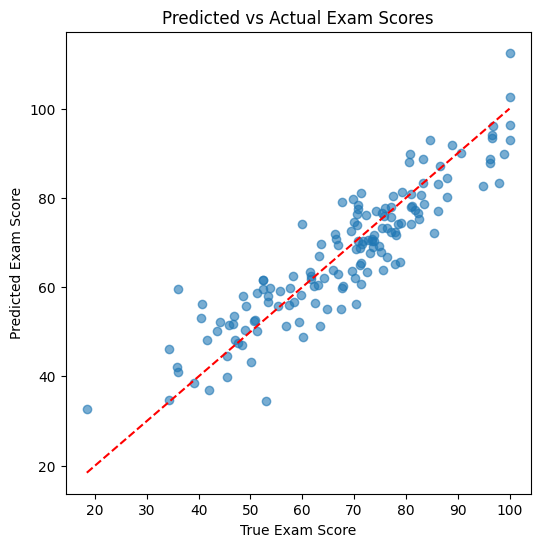

In [13]:
#now lets visualize to confirm resuilts :
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_test, alpha=0.6)
plt.xlabel("True Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Predicted vs Actual Exam Scores")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  # ideal line
plt.show()


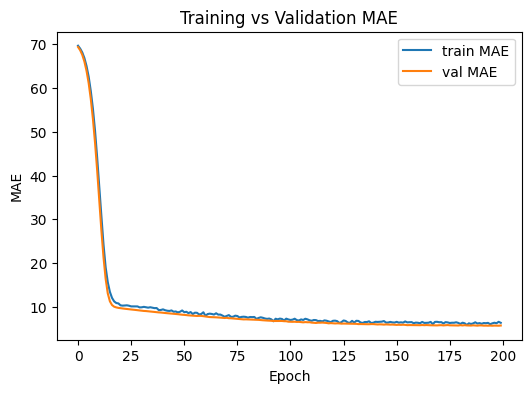

In [14]:
#now lets check under or over-fitting :
plt.figure(figsize=(6,4))
plt.plot(history.history["mae"], label="train MAE")
plt.plot(history.history["val_mae"], label="val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.title("Training vs Validation MAE")
plt.show()


In [15]:
# this section is not necessary but we can check witch feature is more important :
from sklearn.inspection import permutation_importance

results = permutation_importance(
    model, X_test_scaled, y_test,
    scoring='neg_mean_absolute_error', n_repeats=10, random_state=42
)

for i, col in enumerate(x.columns):
    print(f"{col:25s}: {results.importances_mean[i]:.3f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━

In [16]:
# as we expected the most important thing is study per house (kids pls study ;) )


In [17]:
#now we want to do some tunning
#our tunning plan whould be like this 
#a : we test a capacity ==> wider kayers (32 ->64)
#b : Learning rate : 1e-3 ---> 5e-4
#c : Regularization : a little Dropout or L2
# we will do couple of config to pick best val MAE 

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

def build_model(n_features, hidden=(32,16), lr=1e-3, dropout=0.10, l2=0.0):
    model = keras.Sequential([layers.Input(shape=(n_features,))])
    for h in hidden:
        model.add(layers.Dense(h, activation="relu",
                               kernel_regularizer=regularizers.l2(l2) if l2>0 else None))
        if dropout and dropout>0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))  # linear output for regression
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss="mse",
                  metrics=[keras.metrics.MeanAbsoluteError(name="mae")])
    return model


In [19]:
def train_and_score(config):
    model = build_model(
        n_features=X_train_scaled.shape[1],
        hidden=config["hidden"],
        lr=config["lr"],
        dropout=config["dropout"],
        l2=config["l2"]
    )
    early = keras.callbacks.EarlyStopping(monitor="val_mae", patience=10, restore_best_weights=True)
    hist = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=200, batch_size=32, callbacks=[early], verbose=0
    )
    best_val_mae = min(hist.history["val_mae"])
    return model, best_val_mae


In [20]:
configs = [
    {"name":"base_32x16_lr1e-3", "hidden":(32,16), "lr":1e-3, "dropout":0.10, "l2":0.0},
    {"name":"wider_64x32_lr1e-3", "hidden":(64,32), "lr":1e-3, "dropout":0.10, "l2":0.0},
    {"name":"wider_lr5e-4",       "hidden":(64,32), "lr":5e-4, "dropout":0.10, "l2":0.0},
    {"name":"wider_drop0.2_l2_1e-4","hidden":(64,32), "lr":1e-3, "dropout":0.20, "l2":1e-4},
]
results = []
best = (None, 1e9, None)  # (name, val_mae, model)

for cfg in configs:
    m, val_mae = train_and_score(cfg)
    results.append((cfg["name"], val_mae))
    if val_mae < best[1]:
        best = (cfg["name"], val_mae, m)

for name, mae in results:
    print(f"{name:25s}  val_MAE = {mae:.3f}")

best_name, best_val_mae, best_model = best
print("\nBest config ->", best_name, "| val_MAE =", round(best_val_mae,3))


base_32x16_lr1e-3          val_MAE = 5.640
wider_64x32_lr1e-3         val_MAE = 5.650
wider_lr5e-4               val_MAE = 6.142
wider_drop0.2_l2_1e-4      val_MAE = 5.678

Best config -> base_32x16_lr1e-3 | val_MAE = 5.64


thats means that the main first model was already good enough

Project Overview

Goal:
Predict students’ exam scores based on their study and lifestyle habits using a supervised neural network regression model (TensorFlow/Keras).

Dataset:
student_habits_performance.csv — 1,000 students, with 7 numeric features:
age, study_hours_per_day, social_media_hours, attendance_percentage,
sleep_hours, mental_health_rating, and exam_score (target).

| Step                | Description                                          |
| ------------------- | ---------------------------------------------------- |
| **Data Cleaning**   | No missing values; dropped unused columns (like IDs) |
| **Feature Scaling** | StandardScaler for all numeric inputs                |
| **Architecture**    | 2 hidden layers: (64 → 32) neurons, ReLU activations |
| **Regularization**  | Dropout (0.2) + L2 (1e-4)                            |
| **Optimizer**       | Adam (LR = 0.001)                                    |
| **Loss / Metric**   | MSE / MAE                                            |
| **Early Stopping**  | patience = 10 on validation MAE                      |


#our results was :
| Metric                    | Value | Interpretation                               |
| ------------------------- | ----- | -------------------------------------------- |
| **MAE**                   | 5.61  | Avg error ~5.6 score points                  |
| **RMSE**                  | 7.05  | Penalized average error                      |
| **R²**                    | 0.82  | Explains 82% of exam-score variance          |
| **Val MAE (best config)** | ≈ 5.7 | Stable across configs — no over/underfitting |


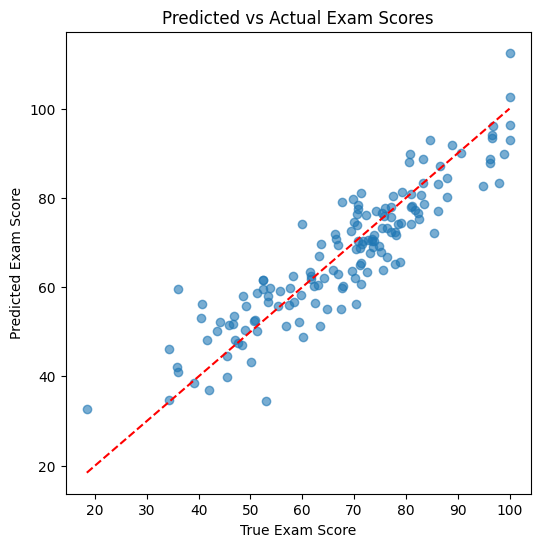

In [21]:
#and most important one was :
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("True Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Predicted vs Actual Exam Scores")
plt.show()
#Interpretation:
#Most points cluster tightly around the red line → the model predicts accurately for most students.

Conclusions:

Study habits, attendance, and lifestyle features (like sleep) have strong predictive value for exam performance.

The neural network generalizes well (R² ≈ 0.82) — meaning it captures real relationships.

Adding small regularization (Dropout + L2) slightly improved validation MAE — confirming robustness.

Further gains would likely come from more varied features (e.g., parental education, test difficulty) rather than deeper models.

now in this part we want to get inputs and test the project,first need to have the file saved.

In [22]:
import joblib

# save model
best_model.save("student_exam_nn_model.h5")

joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [24]:
from tensorflow import keras
import joblib, numpy as np

MODEL_PATH = "student_exam_nn_model.h5"   # works with compile=False
SCALER_PATH = "scaler.pkl"

# 1) load without compiling to avoid metric deserialization issues
model = keras.models.load_model(MODEL_PATH, compile=False)

# 2) re-compile (same as training)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
)

# 3) now we re-save to the new Keras format for future loads
model.save("student_exam_nn_model.keras")
print("Loaded and re-saved model as student_exam_nn_model.keras")

# 4) load scaler
scaler = joblib.load(SCALER_PATH)

feature_names = [
    "age",
    "study_hours_per_day",
    "social_media_hours",
    "attendance_percentage",
    "sleep_hours",
    "mental_health_rating",
]

def predict_exam_score(model, scaler, inputs_dict):
    x = np.array([[inputs_dict[name] for name in feature_names]], dtype=float)
    x_scaled = scaler.transform(x)
    pred = model.predict(x_scaled, verbose=0).ravel()[0]
    return float(np.clip(pred, 0, 100))

def ask_float(prompt, lo=None, hi=None):
    while True:
        try:
            v = float(input(prompt))
            if lo is not None and v < lo: print(f"  min {lo}"); continue
            if hi is not None and v > hi: print(f"  max {hi}"); continue
            return v
        except ValueError:
            print("  not a number, try again.")

def prompt_and_predict():
    print("\nEnter values:")
    vals = {}
    vals["age"] = ask_float("Age (years 16–30): ", 10, 100)
    vals["study_hours_per_day"] = ask_float("Study hours per day (0–12): ", 0, 16)
    vals["social_media_hours"] = ask_float("Social media hours (0–12): ", 0, 24)
    vals["attendance_percentage"] = ask_float("Attendance % (0–100): ", 0, 100)
    vals["sleep_hours"] = ask_float("Sleep hours (0–12): ", 0, 24)
    vals["mental_health_rating"] = ask_float("Mental health rating (1–10): ", 0, 10)
    pred = predict_exam_score(model, scaler, vals)
    print(f"\n📌 Predicted Exam Score: {pred:.1f}/100")
    return pred

# now we can do a example to predict exam score base on inputs given 
example = {
    "age": 20,
    "study_hours_per_day": 3.5,
    "social_media_hours": 1.0,
    "attendance_percentage": 92,
    "sleep_hours": 7.5,
    "mental_health_rating": 8,
}
print("Example prediction:", predict_exam_score(model, scaler, example))


Loaded and re-saved model as student_exam_nn_model.keras
Example prediction: 79.68647003173828


/home/ana/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
